<a href="https://colab.research.google.com/github/timestoreoman-ctrl/big-data-financial-fraud-detection/blob/main/copy_of_financial_fraud_detection_ellipticplusplus_bigdata_organized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scalable Graph-Based Financial Fraud Detection on Elliptic++

This notebook implements the practical part of the Big Data course project. It uses the full Elliptic++ Actors Dataset without sampling, processes the data with PySpark on Google Colab, extracts graph-based features from the address-address transaction network, trains machine learning models for illicit wallet detection, and measures processing time, speedup, and efficiency.


# 1. Environment Setup

This section mounts Google Drive, installs the required libraries, and starts a Spark session in Google Colab.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!apt-get update -qq
!apt-get install -y openjdk-17-jdk-headless -qq
!pip install -q pyspark findspark pyarrow

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
import os
import findspark

# Java path for Colab with OpenJDK 17
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

findspark.init()

from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("EllipticPlusPlus_Fraud_Detection_BigData")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.default.parallelism", "8")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)

print("Spark started successfully")
print("Spark version:", spark.version)
print("Spark master:", spark.sparkContext.master)
print("Default parallelism:", spark.sparkContext.defaultParallelism)

Spark started successfully
Spark version: 4.0.2
Spark master: local[*]
Default parallelism: 8


# 2. Dataset Download

This section prepares the project folders and downloads the full Elliptic++ Actors Dataset files directly from the official source. The dataset is used without sampling or reduction.


In [ ]:
import os
import glob
import shutil

PROJECT_DIR = "/content/drive/MyDrive/BigData_Project"
REPO_DIR = f"{PROJECT_DIR}/EllipticPlusPlus_repo"
DATA_DIR = f"{PROJECT_DIR}/EllipticPlusPlus_Data"
RAW_DIR = f"{DATA_DIR}/raw"
PARQUET_DIR = f"{DATA_DIR}/parquet"
RESULTS_DIR = f"{PROJECT_DIR}/results"
FIGURES_DIR = f"{PROJECT_DIR}/figures"

for path in [PROJECT_DIR, DATA_DIR, RAW_DIR, PARQUET_DIR, RESULTS_DIR, FIGURES_DIR]:
    os.makedirs(path, exist_ok=True)

print("Folders are ready:")
print("PROJECT_DIR:", PROJECT_DIR)
print("REPO_DIR:", REPO_DIR)
print("RAW_DIR:", RAW_DIR)
print("PARQUET_DIR:", PARQUET_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("FIGURES_DIR:", FIGURES_DIR)

Folders are ready:
PROJECT_DIR: /content/drive/MyDrive/BigData_Project
REPO_DIR: /content/drive/MyDrive/BigData_Project/EllipticPlusPlus_repo
RAW_DIR: /content/drive/MyDrive/BigData_Project/EllipticPlusPlus_Data/raw
PARQUET_DIR: /content/drive/MyDrive/BigData_Project/EllipticPlusPlus_Data/parquet
RESULTS_DIR: /content/drive/MyDrive/BigData_Project/results
FIGURES_DIR: /content/drive/MyDrive/BigData_Project/figures


In [ ]:
import os

RAW_DIR = "/content/drive/MyDrive/BigData_Project/EllipticPlusPlus_Data/raw"

files_to_download = {
    "wallets_features.csv": "https://media.githubusercontent.com/media/git-disl/EllipticPlusPlus/main/Actors%20Dataset/wallets_features.csv",
    "wallets_classes.csv": "https://media.githubusercontent.com/media/git-disl/EllipticPlusPlus/main/Actors%20Dataset/wallets_classes.csv",
    "AddrAddr_edgelist.csv": "https://media.githubusercontent.com/media/git-disl/EllipticPlusPlus/main/Actors%20Dataset/AddrAddr_edgelist.csv",
    "AddrTx_edgelist.csv": "https://media.githubusercontent.com/media/git-disl/EllipticPlusPlus/main/Actors%20Dataset/AddrTx_edgelist.csv",
    "TxAddr_edgelist.csv": "https://media.githubusercontent.com/media/git-disl/EllipticPlusPlus/main/Actors%20Dataset/TxAddr_edgelist.csv",
}

for file_name, url in files_to_download.items():
    output_path = os.path.join(RAW_DIR, file_name)
    if os.path.exists(output_path) and os.path.getsize(output_path) > 1024:
        size_mb = os.path.getsize(output_path) / (1024 * 1024)
        print(f"Already exists: {file_name} | {size_mb:.2f} MB")
    else:
        print(f"Downloading: {file_name}")
        !wget -c -O "{output_path}" "{url}"

Already exists: wallets_features.csv | 578.37 MB
Already exists: wallets_classes.csv | 29.01 MB
Already exists: AddrAddr_edgelist.csv | 191.34 MB
Already exists: AddrTx_edgelist.csv | 20.26 MB
Already exists: TxAddr_edgelist.csv | 35.00 MB


In [ ]:
import os
import glob

csv_files = glob.glob(f"{RAW_DIR}/*.csv")

print("CSV files found:", len(csv_files))

for path in csv_files:
    size_mb = os.path.getsize(path) / (1024 * 1024)
    print(f"- {os.path.basename(path)} | {size_mb:.2f} MB")

CSV files found: 5
- wallets_features.csv | 578.37 MB
- wallets_classes.csv | 29.01 MB
- AddrAddr_edgelist.csv | 191.34 MB
- AddrTx_edgelist.csv | 20.26 MB
- TxAddr_edgelist.csv | 35.00 MB


# 3. Data Loading and Parquet Conversion

This section loads the full CSV files using PySpark, checks their schema and size, and converts them to Parquet format for faster repeated processing.


In [ ]:
try:
    spark
    print("Spark is already running.")
    print("Spark version:", spark.version)
    print("Spark master:", spark.sparkContext.master)
    print("Default parallelism:", spark.sparkContext.defaultParallelism)
except NameError:
    print("Spark is not defined. Please run the Spark setup cell first.")

Spark is already running.
Spark version: 4.0.2
Spark master: local[*]
Default parallelism: 8


In [ ]:
import os
import glob
import time

PROJECT_DIR = "/content/drive/MyDrive/BigData_Project"
DATA_DIR = f"{PROJECT_DIR}/EllipticPlusPlus_Data"
RAW_DIR = f"{DATA_DIR}/raw"
PARQUET_DIR = f"{DATA_DIR}/parquet"
RESULTS_DIR = f"{PROJECT_DIR}/results"
FIGURES_DIR = f"{PROJECT_DIR}/figures"

for path in [PARQUET_DIR, RESULTS_DIR, FIGURES_DIR]:
    os.makedirs(path, exist_ok=True)

wallets_features_path = f"{RAW_DIR}/wallets_features.csv"
wallets_classes_path = f"{RAW_DIR}/wallets_classes.csv"
addraddr_edges_path = f"{RAW_DIR}/AddrAddr_edgelist.csv"
addrtx_edges_path = f"{RAW_DIR}/AddrTx_edgelist.csv"
txaddr_edges_path = f"{RAW_DIR}/TxAddr_edgelist.csv"

paths = {
    "wallets_features": wallets_features_path,
    "wallets_classes": wallets_classes_path,
    "addraddr_edges": addraddr_edges_path,
    "addrtx_edges": addrtx_edges_path,
    "txaddr_edges": txaddr_edges_path
}

for name, path in paths.items():
    print(name, "exists:", os.path.exists(path), "|", path)

wallets_features exists: True | /content/drive/MyDrive/BigData_Project/EllipticPlusPlus_Data/raw/wallets_features.csv
wallets_classes exists: True | /content/drive/MyDrive/BigData_Project/EllipticPlusPlus_Data/raw/wallets_classes.csv
addraddr_edges exists: True | /content/drive/MyDrive/BigData_Project/EllipticPlusPlus_Data/raw/AddrAddr_edgelist.csv
addrtx_edges exists: True | /content/drive/MyDrive/BigData_Project/EllipticPlusPlus_Data/raw/AddrTx_edgelist.csv
txaddr_edges exists: True | /content/drive/MyDrive/BigData_Project/EllipticPlusPlus_Data/raw/TxAddr_edgelist.csv


In [ ]:
read_start = time.time()

wallets_features = (
    spark.read
    .option("header", True)
    .option("inferSchema", False)
    .option("mode", "PERMISSIVE")
    .csv(wallets_features_path)
)

wallets_classes = (
    spark.read
    .option("header", True)
    .option("inferSchema", False)
    .option("mode", "PERMISSIVE")
    .csv(wallets_classes_path)
)

addraddr_edges = (
    spark.read
    .option("header", True)
    .option("inferSchema", False)
    .option("mode", "PERMISSIVE")
    .csv(addraddr_edges_path)
)

addrtx_edges = (
    spark.read
    .option("header", True)
    .option("inferSchema", False)
    .option("mode", "PERMISSIVE")
    .csv(addrtx_edges_path)
)

txaddr_edges = (
    spark.read
    .option("header", True)
    .option("inferSchema", False)
    .option("mode", "PERMISSIVE")
    .csv(txaddr_edges_path)
)

read_end = time.time()

print("All CSV files loaded as Spark DataFrames.")
print(f"Read setup time: {read_end - read_start:.2f} seconds")

All CSV files loaded as Spark DataFrames.
Read setup time: 2.81 seconds


In [ ]:
print("wallets_features columns:")
print(wallets_features.columns)

print("\nwallets_classes columns:")
print(wallets_classes.columns)

print("\nAddrAddr_edgelist columns:")
print(addraddr_edges.columns)

print("\nAddrTx_edgelist columns:")
print(addrtx_edges.columns)

print("\nTxAddr_edgelist columns:")
print(txaddr_edges.columns)

wallets_features columns:
['address', 'Time step', 'num_txs_as_sender', 'num_txs_as receiver', 'first_block_appeared_in', 'last_block_appeared_in', 'lifetime_in_blocks', 'total_txs', 'first_sent_block', 'first_received_block', 'num_timesteps_appeared_in', 'btc_transacted_total', 'btc_transacted_min', 'btc_transacted_max', 'btc_transacted_mean', 'btc_transacted_median', 'btc_sent_total', 'btc_sent_min', 'btc_sent_max', 'btc_sent_mean', 'btc_sent_median', 'btc_received_total', 'btc_received_min', 'btc_received_max', 'btc_received_mean', 'btc_received_median', 'fees_total', 'fees_min', 'fees_max', 'fees_mean', 'fees_median', 'fees_as_share_total', 'fees_as_share_min', 'fees_as_share_max', 'fees_as_share_mean', 'fees_as_share_median', 'blocks_btwn_txs_total', 'blocks_btwn_txs_min', 'blocks_btwn_txs_max', 'blocks_btwn_txs_mean', 'blocks_btwn_txs_median', 'blocks_btwn_input_txs_total', 'blocks_btwn_input_txs_min', 'blocks_btwn_input_txs_max', 'blocks_btwn_input_txs_mean', 'blocks_btwn_input_

In [ ]:
def summarize_dataframe(name, df):
    start = time.time()
    row_count = df.count()
    end = time.time()
    col_count = len(df.columns)
    elapsed = end - start

    print(f"{name}")
    print(f"  Rows: {row_count:,}")
    print(f"  Columns: {col_count}")
    print(f"  Count time: {elapsed:.2f} seconds")
    print("-" * 60)

    return {
        "dataset": name,
        "rows": row_count,
        "columns": col_count,
        "count_time_seconds": elapsed
    }

dataset_summaries = []

dataset_summaries.append(summarize_dataframe("wallets_features", wallets_features))
dataset_summaries.append(summarize_dataframe("wallets_classes", wallets_classes))
dataset_summaries.append(summarize_dataframe("AddrAddr_edgelist", addraddr_edges))
dataset_summaries.append(summarize_dataframe("AddrTx_edgelist", addrtx_edges))
dataset_summaries.append(summarize_dataframe("TxAddr_edgelist", txaddr_edges))

dataset_summaries

wallets_features
  Rows: 1,268,260
  Columns: 57
  Count time: 7.01 seconds
------------------------------------------------------------
wallets_classes
  Rows: 822,942
  Columns: 2
  Count time: 1.53 seconds
------------------------------------------------------------
AddrAddr_edgelist
  Rows: 2,868,964
  Columns: 2
  Count time: 3.09 seconds
------------------------------------------------------------
AddrTx_edgelist
  Rows: 477,117
  Columns: 2
  Count time: 0.37 seconds
------------------------------------------------------------
TxAddr_edgelist
  Rows: 837,124
  Columns: 2
  Count time: 0.85 seconds
------------------------------------------------------------


[{'dataset': 'wallets_features',
  'rows': 1268260,
  'columns': 57,
  'count_time_seconds': 7.008101224899292},
 {'dataset': 'wallets_classes',
  'rows': 822942,
  'columns': 2,
  'count_time_seconds': 1.5330390930175781},
 {'dataset': 'AddrAddr_edgelist',
  'rows': 2868964,
  'columns': 2,
  'count_time_seconds': 3.0850512981414795},
 {'dataset': 'AddrTx_edgelist',
  'rows': 477117,
  'columns': 2,
  'count_time_seconds': 0.37128591537475586},
 {'dataset': 'TxAddr_edgelist',
  'rows': 837124,
  'columns': 2,
  'count_time_seconds': 0.8473644256591797}]

In [ ]:
print("wallets_features sample:")
wallets_features.show(5, truncate=False)

print("wallets_classes sample:")
wallets_classes.show(5, truncate=False)

print("AddrAddr_edgelist sample:")
addraddr_edges.show(5, truncate=False)

wallets_features sample:
+---------------------------------+---------+-----------------+-------------------+-----------------------+----------------------+------------------+---------+----------------+--------------------+-------------------------+--------------------+------------------+------------------+-------------------+---------------------+--------------+------------+------------+-------------+---------------+------------------+----------------+----------------+-----------------+-------------------+----------+----------+----------+------------+----------------------+--------------------+----------------------+---------------------+--------------------+--------------------+---------------------+-------------------+-------------------+--------------------+----------------------+---------------------------+-------------------------+-------------------------+--------------------------+----------------------------+----------------------------+--------------------------+--------------

In [ ]:
parquet_start = time.time()

wallets_features.write.mode("overwrite").parquet(f"{PARQUET_DIR}/wallets_features")
wallets_classes.write.mode("overwrite").parquet(f"{PARQUET_DIR}/wallets_classes")
addraddr_edges.write.mode("overwrite").parquet(f"{PARQUET_DIR}/addraddr_edges")
addrtx_edges.write.mode("overwrite").parquet(f"{PARQUET_DIR}/addrtx_edges")
txaddr_edges.write.mode("overwrite").parquet(f"{PARQUET_DIR}/txaddr_edges")

parquet_end = time.time()

print("All full datasets were saved in Parquet format.")
print(f"Parquet conversion time: {parquet_end - parquet_start:.2f} seconds")

All full datasets were saved in Parquet format.
Parquet conversion time: 95.62 seconds


In [ ]:
wallets_features_pq = spark.read.parquet(f"{PARQUET_DIR}/wallets_features")
wallets_classes_pq = spark.read.parquet(f"{PARQUET_DIR}/wallets_classes")
addraddr_edges_pq = spark.read.parquet(f"{PARQUET_DIR}/addraddr_edges")
addrtx_edges_pq = spark.read.parquet(f"{PARQUET_DIR}/addrtx_edges")
txaddr_edges_pq = spark.read.parquet(f"{PARQUET_DIR}/txaddr_edges")

print("Parquet files loaded successfully.")

print("wallets_features:", wallets_features_pq.count())
print("wallets_classes:", wallets_classes_pq.count())
print("addraddr_edges:", addraddr_edges_pq.count())
print("addrtx_edges:", addrtx_edges_pq.count())
print("txaddr_edges:", txaddr_edges_pq.count())

Parquet files loaded successfully.
wallets_features: 1268260
wallets_classes: 822942
addraddr_edges: 2868964
addrtx_edges: 477117
txaddr_edges: 837124


# 4. Data Preprocessing and Label Preparation

This section joins wallet features with class labels, analyzes class distribution, creates the binary fraud label, and saves the labeled datasets.


In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
import os
import time

PROJECT_DIR = "/content/drive/MyDrive/BigData_Project"
DATA_DIR = f"{PROJECT_DIR}/EllipticPlusPlus_Data"
PARQUET_DIR = f"{DATA_DIR}/parquet"
RESULTS_DIR = f"{PROJECT_DIR}/results"

wallets_features = spark.read.parquet(f"{PARQUET_DIR}/wallets_features")
wallets_classes = spark.read.parquet(f"{PARQUET_DIR}/wallets_classes")
addraddr_edges = spark.read.parquet(f"{PARQUET_DIR}/addraddr_edges")
addrtx_edges = spark.read.parquet(f"{PARQUET_DIR}/addrtx_edges")
txaddr_edges = spark.read.parquet(f"{PARQUET_DIR}/txaddr_edges")

print("Loaded Parquet datasets successfully.")
print("wallets_features:", wallets_features.count())
print("wallets_classes:", wallets_classes.count())
print("addraddr_edges:", addraddr_edges.count())

Loaded Parquet datasets successfully.
wallets_features: 1268260
wallets_classes: 822942
addraddr_edges: 2868964


In [ ]:
print("wallets_features columns:")
for i, c in enumerate(wallets_features.columns):
    print(i, c)

print("\nwallets_classes columns:")
for i, c in enumerate(wallets_classes.columns):
    print(i, c)

print("\naddraddr_edges columns:")
for i, c in enumerate(addraddr_edges.columns):
    print(i, c)

wallets_features columns:
0 address
1 Time step
2 num_txs_as_sender
3 num_txs_as receiver
4 first_block_appeared_in
5 last_block_appeared_in
6 lifetime_in_blocks
7 total_txs
8 first_sent_block
9 first_received_block
10 num_timesteps_appeared_in
11 btc_transacted_total
12 btc_transacted_min
13 btc_transacted_max
14 btc_transacted_mean
15 btc_transacted_median
16 btc_sent_total
17 btc_sent_min
18 btc_sent_max
19 btc_sent_mean
20 btc_sent_median
21 btc_received_total
22 btc_received_min
23 btc_received_max
24 btc_received_mean
25 btc_received_median
26 fees_total
27 fees_min
28 fees_max
29 fees_mean
30 fees_median
31 fees_as_share_total
32 fees_as_share_min
33 fees_as_share_max
34 fees_as_share_mean
35 fees_as_share_median
36 blocks_btwn_txs_total
37 blocks_btwn_txs_min
38 blocks_btwn_txs_max
39 blocks_btwn_txs_mean
40 blocks_btwn_txs_median
41 blocks_btwn_input_txs_total
42 blocks_btwn_input_txs_min
43 blocks_btwn_input_txs_max
44 blocks_btwn_input_txs_mean
45 blocks_btwn_input_txs_media

In [ ]:
print("wallets_features sample:")
wallets_features.show(5, truncate=False)

print("wallets_classes sample:")
wallets_classes.show(10, truncate=False)

print("addraddr_edges sample:")
addraddr_edges.show(5, truncate=False)

wallets_features sample:
+----------------------------------+---------+-----------------+-------------------+-----------------------+----------------------+------------------+---------+----------------+--------------------+-------------------------+--------------------+------------------+------------------+-------------------+---------------------+--------------+------------+------------+-------------+---------------+------------------+----------------+----------------+-----------------+-------------------+----------+----------+--------------------+----------+-----------+----------------------+----------------------+----------------------+----------------------+----------------------+---------------------+-------------------+-------------------+--------------------+----------------------+---------------------------+-------------------------+-------------------------+--------------------------+----------------------------+----------------------------+--------------------------+---------

In [ ]:
feature_cols_set = set(wallets_features.columns)
class_cols_set = set(wallets_classes.columns)

common_cols = list(feature_cols_set.intersection(class_cols_set))

print("Common columns between features and classes:")
print(common_cols)

# Detect class column
possible_class_cols = [
    c for c in wallets_classes.columns
    if "class" in c.lower() or "label" in c.lower()
]

print("Possible class columns:", possible_class_cols)

if len(possible_class_cols) == 0:
    raise ValueError("Could not detect class/label column. Please check wallets_classes columns.")

class_col = possible_class_cols[0]

# Detect ID column
possible_id_cols = [c for c in common_cols if c != class_col]

if len(possible_id_cols) == 0:
    raise ValueError("Could not detect common wallet/address ID column.")

id_col = possible_id_cols[0]

print("Detected ID column:", id_col)
print("Detected class column:", class_col)

Common columns between features and classes:
['address']
Possible class columns: ['class']
Detected ID column: address
Detected class column: class


In [ ]:
class_distribution = (
    wallets_classes
    .groupBy(class_col)
    .count()
    .orderBy(class_col)
)

class_distribution.show(truncate=False)

class_distribution.write.mode("overwrite").csv(
    f"{RESULTS_DIR}/class_distribution_raw",
    header=True
)

+-----+------+
|class|count |
+-----+------+
|1    |14266 |
|2    |251088|
|3    |557588|
+-----+------+



In [ ]:
join_start = time.time()

wallets_labeled_full = (
    wallets_features
    .join(wallets_classes, on=id_col, how="left")
)

join_count = wallets_labeled_full.count()
join_end = time.time()

print("Joined features with classes.")
print("Rows after join:", f"{join_count:,}")
print("Join time:", f"{join_end - join_start:.2f} seconds")

wallets_labeled_full.show(5, truncate=False)

Joined features with classes.
Rows after join: 1,268,260
Join time: 6.97 seconds
+----------------------------------+---------+-----------------+-------------------+-----------------------+----------------------+------------------+---------+----------------+--------------------+-------------------------+--------------------+------------------+------------------+-------------------+---------------------+--------------+------------+------------+-------------+---------------+------------------+----------------+----------------+-----------------+-------------------+----------+----------+----------+----------+-----------+---------------------+--------------------+---------------------+--------------------+--------------------+---------------------+-------------------+-------------------+--------------------+----------------------+---------------------------+-------------------------+-------------------------+--------------------------+----------------------------+---------------------------

In [ ]:
# Standardize class column as integer
wallets_labeled_full = wallets_labeled_full.withColumn(
    class_col,
    F.col(class_col).cast("int")
)

# Keep only known labels for supervised classification
wallets_known = wallets_labeled_full.filter(F.col(class_col).isin([1, 2]))

# Convert labels:
# illicit class 1 -> fraud_label = 1
# licit class 2   -> fraud_label = 0
wallets_known = wallets_known.withColumn(
    "fraud_label",
    F.when(F.col(class_col) == 1, F.lit(1)).otherwise(F.lit(0))
)

print("Full joined rows:", wallets_labeled_full.count())
print("Known labeled rows for supervised ML:", wallets_known.count())

wallets_known.groupBy("fraud_label").count().orderBy("fraud_label").show()

Full joined rows: 1268260
Known labeled rows for supervised ML: 367472
+-----------+------+
|fraud_label| count|
+-----------+------+
|          0|338871|
|          1| 28601|
+-----------+------+



In [ ]:
label_counts = wallets_known.groupBy("fraud_label").count().collect()

counts_dict = {row["fraud_label"]: row["count"] for row in label_counts}

licit_count = counts_dict.get(0, 0)
illicit_count = counts_dict.get(1, 0)
total_known = licit_count + illicit_count

print("Known labeled records:", f"{total_known:,}")
print("Licit records:", f"{licit_count:,}")
print("Illicit records:", f"{illicit_count:,}")

if total_known > 0:
    print("Illicit percentage:", f"{(illicit_count / total_known) * 100:.4f}%")
    print("Licit percentage:", f"{(licit_count / total_known) * 100:.4f}%")

Known labeled records: 367,472
Licit records: 338,871
Illicit records: 28,601
Illicit percentage: 7.7832%
Licit percentage: 92.2168%


In [ ]:
save_start = time.time()

wallets_labeled_full.write.mode("overwrite").parquet(
    f"{PARQUET_DIR}/wallets_labeled_full"
)

wallets_known.write.mode("overwrite").parquet(
    f"{PARQUET_DIR}/wallets_known_labeled"
)

save_end = time.time()

print("Saved labeled datasets as Parquet.")
print("Save time:", f"{save_end - save_start:.2f} seconds")

Saved labeled datasets as Parquet.
Save time: 162.19 seconds


# 5. Graph Feature Engineering

This section extracts graph-based degree features from the address-address edge list and merges them with the labeled wallet dataset.


In [ ]:
from pyspark.sql import functions as F
import time
import os

PROJECT_DIR = "/content/drive/MyDrive/BigData_Project"
DATA_DIR = f"{PROJECT_DIR}/EllipticPlusPlus_Data"
PARQUET_DIR = f"{DATA_DIR}/parquet"
RESULTS_DIR = f"{PROJECT_DIR}/results"

wallets_labeled_full = spark.read.parquet(f"{PARQUET_DIR}/wallets_labeled_full")
wallets_known = spark.read.parquet(f"{PARQUET_DIR}/wallets_known_labeled")
addraddr_edges = spark.read.parquet(f"{PARQUET_DIR}/addraddr_edges")

print("wallets_labeled_full:", wallets_labeled_full.count())
print("wallets_known:", wallets_known.count())
print("addraddr_edges:", addraddr_edges.count())

print("\nwallets_known columns:")
print(wallets_known.columns)

print("\naddraddr_edges columns:")
print(addraddr_edges.columns)

wallets_labeled_full: 1268260
wallets_known: 367472
addraddr_edges: 2868964

wallets_known columns:
['address', 'Time step', 'num_txs_as_sender', 'num_txs_as receiver', 'first_block_appeared_in', 'last_block_appeared_in', 'lifetime_in_blocks', 'total_txs', 'first_sent_block', 'first_received_block', 'num_timesteps_appeared_in', 'btc_transacted_total', 'btc_transacted_min', 'btc_transacted_max', 'btc_transacted_mean', 'btc_transacted_median', 'btc_sent_total', 'btc_sent_min', 'btc_sent_max', 'btc_sent_mean', 'btc_sent_median', 'btc_received_total', 'btc_received_min', 'btc_received_max', 'btc_received_mean', 'btc_received_median', 'fees_total', 'fees_min', 'fees_max', 'fees_mean', 'fees_median', 'fees_as_share_total', 'fees_as_share_min', 'fees_as_share_max', 'fees_as_share_mean', 'fees_as_share_median', 'blocks_btwn_txs_total', 'blocks_btwn_txs_min', 'blocks_btwn_txs_max', 'blocks_btwn_txs_mean', 'blocks_btwn_txs_median', 'blocks_btwn_input_txs_total', 'blocks_btwn_input_txs_min', 'blo

In [ ]:
# Detect class column
possible_class_cols = [
    c for c in wallets_labeled_full.columns
    if "class" in c.lower() or "label" in c.lower()
]

if len(possible_class_cols) == 0:
    raise ValueError("Could not detect class/label column.")

class_col = possible_class_cols[0]

# Detect wallet ID column from common columns between labeled data and original classes/features
# Usually this will be something like address, wallet, or address_id
possible_id_cols = [
    c for c in wallets_labeled_full.columns
    if c.lower() in ["address", "wallet", "wallet_address", "address_id", "id"]
]

if len(possible_id_cols) == 0:
    # fallback: use first non-feature, non-label column
    possible_id_cols = [
        c for c in wallets_labeled_full.columns
        if c != class_col and c != "fraud_label" and not c.lower().startswith("feature")
    ]

id_col = possible_id_cols[0]

print("Detected wallet ID column:", id_col)
print("Detected class column:", class_col)

# Detect source and destination columns in AddrAddr edge list
edge_cols = addraddr_edges.columns
print("Edge columns:", edge_cols)

possible_src_names = ["source", "src", "from", "input", "input_address", "txId1", "addr1"]
possible_dst_names = ["target", "dst", "to", "output", "output_address", "txId2", "addr2"]

src_col = None
dst_col = None

for c in edge_cols:
    if c.lower() in [x.lower() for x in possible_src_names]:
        src_col = c
    if c.lower() in [x.lower() for x in possible_dst_names]:
        dst_col = c

# fallback: use first two columns
if src_col is None or dst_col is None:
    src_col = edge_cols[0]
    dst_col = edge_cols[1]

print("Detected source column:", src_col)
print("Detected destination column:", dst_col)

Detected wallet ID column: address
Detected class column: class
Edge columns: ['input_address', 'output_address']
Detected source column: input_address
Detected destination column: output_address


In [ ]:
degree_start = time.time()

out_degree = (
    addraddr_edges
    .groupBy(F.col(src_col).alias(id_col))
    .agg(F.count("*").alias("out_degree"))
)

in_degree = (
    addraddr_edges
    .groupBy(F.col(dst_col).alias(id_col))
    .agg(F.count("*").alias("in_degree"))
)

degree_end = time.time()

print("Degree features calculated.")
print("Time:", f"{degree_end - degree_start:.2f} seconds")

print("Out-degree sample:")
out_degree.show(5, truncate=False)

print("In-degree sample:")
in_degree.show(5, truncate=False)

Degree features calculated.
Time: 0.07 seconds
Out-degree sample:
+----------------------------------+----------+
|address                           |out_degree|
+----------------------------------+----------+
|1A413YVi2bhyDa9zntqZkSKRagfcKL3G6D|2         |
|176xHDtQwPV1ckM2kdrcisAwiTVPgURLCz|2         |
|1Dc5M7GqU2zks8CQJoMyL3CGF56dt7hf42|2         |
|14sXCMtXKQ4a1weFZTHjsjND6Pqa5ZNAzu|2         |
|17hMh6N568KhPfLkns3iFArgkFdGAbqRMG|2         |
+----------------------------------+----------+
only showing top 5 rows
In-degree sample:
+----------------------------------+---------+
|address                           |in_degree|
+----------------------------------+---------+
|1B4u11sR38mvaneFnCF45p2LCAS4caJVfx|1        |
|37VKmqGVhnGfNmsweA6vDt8HRYovBgN6V5|1        |
|1Gs44QWEiJ1FqfbGiviiBujvXJKaFFiuhs|7        |
|3HFaT6aqJ2oSJKfe4d5nBZR76RxiEALD4m|7        |
|12oyZu49ZXnnR65CxNR4Spzy6V19r3Uwfy|8        |
+----------------------------------+---------+
only showing top 5 rows


In [ ]:
graph_features_start = time.time()

graph_features = (
    out_degree
    .join(in_degree, on=id_col, how="full")
    .fillna({"out_degree": 0, "in_degree": 0})
    .withColumn("total_degree", F.col("out_degree") + F.col("in_degree"))
    .withColumn(
        "in_out_ratio",
        F.when(F.col("out_degree") == 0, F.col("in_degree"))
         .otherwise(F.col("in_degree") / F.col("out_degree"))
    )
)

graph_features_count = graph_features.count()

graph_features_end = time.time()

print("Graph features created.")
print("Rows:", f"{graph_features_count:,}")
print("Time:", f"{graph_features_end - graph_features_start:.2f} seconds")

graph_features.show(10, truncate=False)

Graph features created.
Rows: 822,942
Time: 7.46 seconds
+----------------------------------+----------+---------+------------+------------+
|address                           |out_degree|in_degree|total_degree|in_out_ratio|
+----------------------------------+----------+---------+------------+------------+
|111112TykSw72ztDN2WJger4cynzWYC5w |0         |24       |24          |24.0        |
|111218KKkh1JJFRHbwM16AwCiVCc4m7he1|2         |2        |4           |1.0         |
|111FJppFVhFYWPDagaAxp24U6zb7gAyv4 |0         |1        |1           |1.0         |
|111hUsP6Ekt8ahaEYZUCUTK4svAuKc5Gt |0         |1        |1           |1.0         |
|11216oX1YSABzxhs3vCm1RSssyHzAnTxVh|2         |0        |2           |0.0         |
|1122EeCxhpTn17NnPzSjeZ7Xci2WiZkyVD|1         |1        |2           |1.0         |
|1122eFHVNscGneS8ksavvFKw4tHQtkCYnZ|1         |0        |1           |0.0         |
|1123VmM6fcxDcZF2kSrzn7wQdzuf4peCFc|2         |0        |2           |0.0         |
|1123YDK4FDDwpE5URj

In [ ]:
merge_graph_start = time.time()

wallets_known_graph = (
    wallets_known
    .join(graph_features, on=id_col, how="left")
    .fillna({
        "out_degree": 0,
        "in_degree": 0,
        "total_degree": 0,
        "in_out_ratio": 0
    })
)

wallets_known_graph_count = wallets_known_graph.count()

merge_graph_end = time.time()

print("Graph features merged with known labeled wallets.")
print("Rows:", f"{wallets_known_graph_count:,}")
print("Merge time:", f"{merge_graph_end - merge_graph_start:.2f} seconds")

wallets_known_graph.select(
    id_col,
    class_col,
    "fraud_label",
    "out_degree",
    "in_degree",
    "total_degree",
    "in_out_ratio"
).show(10, truncate=False)

Graph features merged with known labeled wallets.
Rows: 367,472
Merge time: 17.85 seconds
+----------------------------------+-----+-----------+----------+---------+------------+------------+
|address                           |class|fraud_label|out_degree|in_degree|total_degree|in_out_ratio|
+----------------------------------+-----+-----------+----------+---------+------------+------------+
|111112TykSw72ztDN2WJger4cynzWYC5w |2    |0          |0         |24       |24          |24.0        |
|111hUsP6Ekt8ahaEYZUCUTK4svAuKc5Gt |2    |0          |0         |1        |1           |1.0         |
|1125qbgf3KUy8odp4VSA3B5CFshqdKFrYu|2    |0          |0         |1        |1           |1.0         |
|1126xWUTuv7BPUPLPMyPrtzUrknzZ5ByqC|2    |0          |2         |12       |14          |6.0         |
|1126xWUTuv7BPUPLPMyPrtzUrknzZ5ByqC|2    |0          |2         |12       |14          |6.0         |
|112AeoNPQj71dS21AEUFBeajon7Gu9VqGr|2    |0          |0         |1        |1           |1.0   

In [ ]:
save_graph_start = time.time()

wallets_known_graph.write.mode("overwrite").parquet(
    f"{PARQUET_DIR}/wallets_known_graph_features"
)

graph_features.write.mode("overwrite").parquet(
    f"{PARQUET_DIR}/graph_degree_features"
)

save_graph_end = time.time()

print("Saved graph-enhanced datasets.")
print("Save time:", f"{save_graph_end - save_graph_start:.2f} seconds")

Saved graph-enhanced datasets.
Save time: 56.07 seconds


In [ ]:
summary_start = time.time()

known_count = wallets_known_graph.count()
fraud_counts = wallets_known_graph.groupBy("fraud_label").count().orderBy("fraud_label")
degree_stats = wallets_known_graph.select(
    "out_degree",
    "in_degree",
    "total_degree",
    "in_out_ratio"
).summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max")

summary_end = time.time()

print("Known labeled records with graph features:", f"{known_count:,}")
print("\nClass distribution:")
fraud_counts.show()

print("\nGraph feature statistics:")
degree_stats.show(truncate=False)

print("Summary time:", f"{summary_end - summary_start:.2f} seconds")

Known labeled records with graph features: 367,472

Class distribution:
+-----------+------+
|fraud_label| count|
+-----------+------+
|          0|338871|
|          1| 28601|
+-----------+------+


Graph feature statistics:
+-------+-----------------+-----------------+-----------------+------------------+
|summary|out_degree       |in_degree        |total_degree     |in_out_ratio      |
+-------+-----------------+-----------------+-----------------+------------------+
|count  |367472           |367472           |367472           |367472            |
|mean   |72.99627726738363|65.77448077676667|138.7707580441503|5.448590198824223 |
|stddev |620.3494286636156|452.1887596479055|896.519152231428 |20.265674563564623|
|min    |0                |0                |1                |0.0               |
|25%    |0                |0                |2                |0.0               |
|50%    |1                |2                |3                |1.0               |
|75%    |2                |

# 6. Model Preparation

This section prepares numeric feature columns, handles class imbalance using class weights, performs the train/test split, and defines the evaluation function.


In [ ]:
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
import time
import os

PROJECT_DIR = "/content/drive/MyDrive/BigData_Project"
DATA_DIR = f"{PROJECT_DIR}/EllipticPlusPlus_Data"
PARQUET_DIR = f"{DATA_DIR}/parquet"
RESULTS_DIR = f"{PROJECT_DIR}/results"

wallets_known_graph = spark.read.parquet(
    f"{PARQUET_DIR}/wallets_known_graph_features"
)

print("Loaded wallets_known_graph")
print("Rows:", wallets_known_graph.count())
print("Columns:", len(wallets_known_graph.columns))

Loaded wallets_known_graph
Rows: 367472
Columns: 63


In [ ]:
columns = wallets_known_graph.columns

# Detect label/class columns
class_candidates = [c for c in columns if "class" in c.lower() and c != "fraud_label"]
class_col = class_candidates[0] if class_candidates else None

# Detect ID column: usually first non-feature column
id_candidates = [
    c for c in columns
    if c.lower() in ["address", "wallet", "wallet_address", "address_id", "id"]
]

if len(id_candidates) == 0:
    excluded = {"fraud_label"}
    if class_col:
        excluded.add(class_col)
    id_candidates = [
        c for c in columns
        if c not in excluded
        and not c.lower().startswith("feature")
        and c not in ["out_degree", "in_degree", "total_degree", "in_out_ratio"]
    ]

id_col = id_candidates[0]

print("Detected ID column:", id_col)
print("Detected class column:", class_col)
print("Label column: fraud_label")

Detected ID column: address
Detected class column: class
Label column: fraud_label


In [ ]:
graph_feature_cols = [
    "out_degree",
    "in_degree",
    "total_degree",
    "in_out_ratio"
]

excluded_cols = set([id_col, "fraud_label"])
if class_col:
    excluded_cols.add(class_col)

# Original features = كل الأعمدة ما عدا ID, class, label, graph features
original_feature_cols = [
    c for c in wallets_known_graph.columns
    if c not in excluded_cols
    and c not in graph_feature_cols
]

enhanced_feature_cols = original_feature_cols + graph_feature_cols

print("Number of original features:", len(original_feature_cols))
print("Number of graph features:", len(graph_feature_cols))
print("Number of enhanced features:", len(enhanced_feature_cols))

print("\nFirst 10 original features:")
print(original_feature_cols[:10])

print("\nGraph features:")
print(graph_feature_cols)

Number of original features: 56
Number of graph features: 4
Number of enhanced features: 60

First 10 original features:
['Time step', 'num_txs_as_sender', 'num_txs_as receiver', 'first_block_appeared_in', 'last_block_appeared_in', 'lifetime_in_blocks', 'total_txs', 'first_sent_block', 'first_received_block', 'num_timesteps_appeared_in']

Graph features:
['out_degree', 'in_degree', 'total_degree', 'in_out_ratio']


In [ ]:
cast_start = time.time()

model_df = wallets_known_graph

for c in enhanced_feature_cols:
    model_df = model_df.withColumn(c, F.col(c).cast("double"))

model_df = model_df.withColumn("fraud_label", F.col("fraud_label").cast("double"))

# Replace nulls in numeric features with 0
fill_values = {c: 0.0 for c in enhanced_feature_cols}
model_df = model_df.fillna(fill_values)

cast_end = time.time()

print("Feature casting completed.")
print("Time:", f"{cast_end - cast_start:.2f} seconds")
print("Rows:", model_df.count())

Feature casting completed.
Time: 1.38 seconds
Rows: 367472


In [ ]:
label_counts = model_df.groupBy("fraud_label").count().collect()
label_count_dict = {row["fraud_label"]: row["count"] for row in label_counts}

negative_count = label_count_dict.get(0.0, 0)
positive_count = label_count_dict.get(1.0, 0)
total_count = negative_count + positive_count

weight_for_0 = total_count / (2.0 * negative_count)
weight_for_1 = total_count / (2.0 * positive_count)

print("Negative / licit count:", negative_count)
print("Positive / illicit count:", positive_count)
print("Weight for licit class:", weight_for_0)
print("Weight for illicit class:", weight_for_1)

model_df = model_df.withColumn(
    "class_weight",
    F.when(F.col("fraud_label") == 1.0, F.lit(weight_for_1)).otherwise(F.lit(weight_for_0))
)

model_df.select("fraud_label", "class_weight").show(5)

Negative / licit count: 338871
Positive / illicit count: 28601
Weight for licit class: 0.5422004243502689
Weight for illicit class: 6.424111045068354
+-----------+------------------+
|fraud_label|      class_weight|
+-----------+------------------+
|        0.0|0.5422004243502689|
|        0.0|0.5422004243502689|
|        0.0|0.5422004243502689|
|        0.0|0.5422004243502689|
|        0.0|0.5422004243502689|
+-----------+------------------+
only showing top 5 rows


In [ ]:
time_candidates = [
    c for c in model_df.columns
    if "time" in c.lower() or "step" in c.lower() or "timestamp" in c.lower()
]

print("Possible time columns:", time_candidates)

if len(time_candidates) > 0:
    time_col = time_candidates[0]
    print("Using temporal split based on:", time_col)

    model_df = model_df.withColumn(time_col, F.col(time_col).cast("double"))

    threshold = model_df.approxQuantile(time_col, [0.8], 0.01)[0]

    train_df = model_df.filter(F.col(time_col) <= threshold)
    test_df = model_df.filter(F.col(time_col) > threshold)

    split_method = f"Temporal split using {time_col} <= {threshold}"
else:
    print("No time column detected. Using reproducible random split.")

    train_df, test_df = model_df.randomSplit([0.8, 0.2], seed=42)
    split_method = "Random split with seed=42"

print("Split method:", split_method)
print("Train rows:", train_df.count())
print("Test rows:", test_df.count())

print("\nTrain label distribution:")
train_df.groupBy("fraud_label").count().show()

print("\nTest label distribution:")
test_df.groupBy("fraud_label").count().show()

Possible time columns: ['Time step', 'lifetime_in_blocks', 'num_timesteps_appeared_in']
Using temporal split based on: Time step
Split method: Temporal split using Time step <= 41.0
Train rows: 297577
Test rows: 69895

Train label distribution:
+-----------+------+
|fraud_label| count|
+-----------+------+
|        1.0| 24835|
|        0.0|272742|
+-----------+------+


Test label distribution:
+-----------+-----+
|fraud_label|count|
+-----------+-----+
|        1.0| 3766|
|        0.0|66129|
+-----------+-----+



In [ ]:
def evaluate_predictions(predictions, model_name, training_time, prediction_time):
    binary_evaluator_roc = BinaryClassificationEvaluator(
        labelCol="fraud_label",
        rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    )

    binary_evaluator_pr = BinaryClassificationEvaluator(
        labelCol="fraud_label",
        rawPredictionCol="rawPrediction",
        metricName="areaUnderPR"
    )

    accuracy_evaluator = MulticlassClassificationEvaluator(
        labelCol="fraud_label",
        predictionCol="prediction",
        metricName="accuracy"
    )

    f1_evaluator = MulticlassClassificationEvaluator(
        labelCol="fraud_label",
        predictionCol="prediction",
        metricName="f1"
    )

    precision_evaluator = MulticlassClassificationEvaluator(
        labelCol="fraud_label",
        predictionCol="prediction",
        metricName="weightedPrecision"
    )

    recall_evaluator = MulticlassClassificationEvaluator(
        labelCol="fraud_label",
        predictionCol="prediction",
        metricName="weightedRecall"
    )

    roc_auc = binary_evaluator_roc.evaluate(predictions)
    pr_auc = binary_evaluator_pr.evaluate(predictions)
    accuracy = accuracy_evaluator.evaluate(predictions)
    f1 = f1_evaluator.evaluate(predictions)
    weighted_precision = precision_evaluator.evaluate(predictions)
    weighted_recall = recall_evaluator.evaluate(predictions)

    confusion = (
        predictions
        .groupBy("fraud_label", "prediction")
        .count()
        .collect()
    )

    confusion_dict = {
        (row["fraud_label"], row["prediction"]): row["count"]
        for row in confusion
    }

    tn = confusion_dict.get((0.0, 0.0), 0)
    fp = confusion_dict.get((0.0, 1.0), 0)
    fn = confusion_dict.get((1.0, 0.0), 0)
    tp = confusion_dict.get((1.0, 1.0), 0)

    fraud_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    fraud_recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fraud_f1 = (
        2 * fraud_precision * fraud_recall / (fraud_precision + fraud_recall)
        if (fraud_precision + fraud_recall) > 0
        else 0
    )

    metrics = {
        "model": model_name,
        "accuracy": accuracy,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "fraud_precision": fraud_precision,
        "fraud_recall": fraud_recall,
        "fraud_f1": fraud_f1,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "training_time_seconds": training_time,
        "prediction_time_seconds": prediction_time
    }

    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print("Accuracy:", accuracy)
    print("Weighted Precision:", weighted_precision)
    print("Weighted Recall:", weighted_recall)
    print("Weighted F1:", f1)
    print("ROC-AUC:", roc_auc)
    print("PR-AUC:", pr_auc)
    print("Fraud Precision:", fraud_precision)
    print("Fraud Recall:", fraud_recall)
    print("Fraud F1:", fraud_f1)
    print("Confusion Matrix:")
    print("TN:", tn, "FP:", fp)
    print("FN:", fn, "TP:", tp)
    print("Training time:", training_time)
    print("Prediction time:", prediction_time)

    return metrics

# 7. Model Training and Evaluation

This section trains Logistic Regression and Random Forest models, evaluates their predictive performance, and saves the model outputs.


In [ ]:
baseline_start = time.time()

baseline_assembler = VectorAssembler(
    inputCols=original_feature_cols,
    outputCol="features",
    handleInvalid="keep"
)

baseline_train = baseline_assembler.transform(train_df).select(
    "features",
    "fraud_label",
    "class_weight"
)

baseline_test = baseline_assembler.transform(test_df).select(
    "features",
    "fraud_label",
    "class_weight"
)

lr_baseline = LogisticRegression(
    featuresCol="features",
    labelCol="fraud_label",
    weightCol="class_weight",
    maxIter=50,
    regParam=0.01,
    elasticNetParam=0.0
)

train_start = time.time()
lr_baseline_model = lr_baseline.fit(baseline_train)
train_end = time.time()

pred_start = time.time()
baseline_predictions = lr_baseline_model.transform(baseline_test)
baseline_predictions.cache()
baseline_predictions.count()
pred_end = time.time()

baseline_end = time.time()

baseline_metrics = evaluate_predictions(
    baseline_predictions,
    "Baseline Logistic Regression - Original Features",
    train_end - train_start,
    pred_end - pred_start
)

print("Total baseline pipeline time:", f"{baseline_end - baseline_start:.2f} seconds")

Baseline Logistic Regression - Original Features
Accuracy: 0.5566063380785464
Weighted Precision: 0.9349987724117965
Weighted Recall: 0.5566063380785463
Weighted F1: 0.669177883586995
ROC-AUC: 0.7320768933204124
PR-AUC: 0.17382360656360496
Fraud Precision: 0.09381434070360756
Fraud Recall: 0.8348380244291025
Fraud F1: 0.1686740524155691
Confusion Matrix:
TN: 35760 FP: 30369
FN: 622 TP: 3144
Training time: 50.52128553390503
Prediction time: 5.833073377609253
Total baseline pipeline time: 56.58 seconds


In [ ]:
enhanced_start = time.time()

enhanced_assembler = VectorAssembler(
    inputCols=enhanced_feature_cols,
    outputCol="features",
    handleInvalid="keep"
)

enhanced_train = enhanced_assembler.transform(train_df).select(
    "features",
    "fraud_label",
    "class_weight"
)

enhanced_test = enhanced_assembler.transform(test_df).select(
    "features",
    "fraud_label",
    "class_weight"
)

lr_enhanced = LogisticRegression(
    featuresCol="features",
    labelCol="fraud_label",
    weightCol="class_weight",
    maxIter=50,
    regParam=0.01,
    elasticNetParam=0.0
)

train_start = time.time()
lr_enhanced_model = lr_enhanced.fit(enhanced_train)
train_end = time.time()

pred_start = time.time()
enhanced_predictions = lr_enhanced_model.transform(enhanced_test)
enhanced_predictions.cache()
enhanced_predictions.count()
pred_end = time.time()

enhanced_end = time.time()

enhanced_metrics = evaluate_predictions(
    enhanced_predictions,
    "Graph-Enhanced Logistic Regression",
    train_end - train_start,
    pred_end - pred_start
)

print("Total enhanced pipeline time:", f"{enhanced_end - enhanced_start:.2f} seconds")

Graph-Enhanced Logistic Regression
Accuracy: 0.5548751698977037
Weighted Precision: 0.9348206361242803
Weighted Recall: 0.5548751698977037
Weighted F1: 0.667705251663368
ROC-AUC: 0.7326349682788611
PR-AUC: 0.17043528596025945
Fraud Precision: 0.09338012252423719
Fraud Recall: 0.8337758895379713
Fraud F1: 0.16795036371416344
Confusion Matrix:
TN: 35643 FP: 30486
FN: 626 TP: 3140
Training time: 49.6318781375885
Prediction time: 7.56121301651001
Total enhanced pipeline time: 57.98 seconds


In [ ]:
metrics_list = [baseline_metrics, enhanced_metrics]

metrics_df = spark.createDataFrame(metrics_list)

metrics_df.show(truncate=False)

metrics_df.write.mode("overwrite").csv(
    f"{RESULTS_DIR}/model_metrics_comparison",
    header=True
)

print("Metrics saved to:", f"{RESULTS_DIR}/model_metrics_comparison")

+------------------+---+-----+-------------------+-------------------+------------------+------------------------------------------------+-------------------+-----------------------+------------------+-----+----+---------------------+-----------------+------------------+------------------+
|accuracy          |fn |fp   |fraud_f1           |fraud_precision    |fraud_recall      |model                                           |pr_auc             |prediction_time_seconds|roc_auc           |tn   |tp  |training_time_seconds|weighted_f1      |weighted_precision|weighted_recall   |
+------------------+---+-----+-------------------+-------------------+------------------+------------------------------------------------+-------------------+-----------------------+------------------+-----+----+---------------------+-----------------+------------------+------------------+
|0.5566063380785464|622|30369|0.1686740524155691 |0.09381434070360756|0.8348380244291025|Baseline Logistic Regression - Origina

In [ ]:
baseline_predictions.write.mode("overwrite").parquet(
    f"{PARQUET_DIR}/baseline_predictions"
)

enhanced_predictions.write.mode("overwrite").parquet(
    f"{PARQUET_DIR}/enhanced_predictions"
)

print("Predictions saved successfully.")

Predictions saved successfully.


In [ ]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.feature import VectorAssembler
import time

rf_start = time.time()

rf_assembler = VectorAssembler(
    inputCols=enhanced_feature_cols,
    outputCol="features",
    handleInvalid="keep"
)

rf_train = rf_assembler.transform(train_df).select(
    "features",
    "fraud_label",
    "class_weight"
)

rf_test = rf_assembler.transform(test_df).select(
    "features",
    "fraud_label",
    "class_weight"
)

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="fraud_label",
    weightCol="class_weight",
    numTrees=80,
    maxDepth=10,
    seed=42,
    maxBins=32
)

train_start = time.time()
rf_model = rf.fit(rf_train)
train_end = time.time()

pred_start = time.time()
rf_predictions = rf_model.transform(rf_test)
rf_predictions.cache()
rf_predictions.count()
pred_end = time.time()

rf_end = time.time()

rf_metrics = evaluate_predictions(
    rf_predictions,
    "Graph-Enhanced Random Forest",
    train_end - train_start,
    pred_end - pred_start
)

print("Total Random Forest pipeline time:", f"{rf_end - rf_start:.2f} seconds")

Graph-Enhanced Random Forest
Accuracy: 0.8936547678660849
Weighted Precision: 0.9328280416581124
Weighted Recall: 0.8936547678660849
Weighted F1: 0.9100330026355131
ROC-AUC: 0.8482036594866758
PR-AUC: 0.41916134035432034
Fraud Precision: 0.25909867297332806
Fraud Recall: 0.5236325013276686
Fraud F1: 0.34666432275643844
Confusion Matrix:
TN: 60490 FP: 5639
FN: 1794 TP: 1972
Training time: 226.94590210914612
Prediction time: 12.704018592834473
Total Random Forest pipeline time: 239.82 seconds


In [ ]:
PROJECT_DIR = "/content/drive/MyDrive/BigData_Project"
RESULTS_DIR = f"{PROJECT_DIR}/results"
DATA_DIR = f"{PROJECT_DIR}/EllipticPlusPlus_Data"
PARQUET_DIR = f"{DATA_DIR}/parquet"

all_metrics_df = spark.read.csv(
    f"{RESULTS_DIR}/all_model_metrics_comparison",
    header=True,
    inferSchema=True
)

all_metrics_df.show(truncate=False)

rf_predictions = spark.read.parquet(
    f"{PARQUET_DIR}/rf_graph_enhanced_predictions"
)

print("RF predictions loaded:", rf_predictions.count())

+------------------+----+-----+-------------------+-------------------+------------------+------------------------------------------------+-------------------+-----------------------+------------------+-----+----+---------------------+------------------+------------------+------------------+
|accuracy          |fn  |fp   |fraud_f1           |fraud_precision    |fraud_recall      |model                                           |pr_auc             |prediction_time_seconds|roc_auc           |tn   |tp  |training_time_seconds|weighted_f1       |weighted_precision|weighted_recall   |
+------------------+----+-----+-------------------+-------------------+------------------+------------------------------------------------+-------------------+-----------------------+------------------+-----+----+---------------------+------------------+------------------+------------------+
|0.5566063380785464|622 |30369|0.1686740524155691 |0.09381434070360756|0.8348380244291025|Baseline Logistic Regression - 

In [ ]:
all_metrics_list = [baseline_metrics, enhanced_metrics, rf_metrics]

all_metrics_df = spark.createDataFrame(all_metrics_list)

all_metrics_df.select(
    "model",
    "accuracy",
    "roc_auc",
    "pr_auc",
    "fraud_precision",
    "fraud_recall",
    "fraud_f1",
    "training_time_seconds",
    "prediction_time_seconds",
    "tn",
    "fp",
    "fn",
    "tp"
).show(truncate=False)

all_metrics_df.write.mode("overwrite").csv(
    f"{RESULTS_DIR}/all_model_metrics_comparison",
    header=True
)

print("All model metrics saved to:", f"{RESULTS_DIR}/all_model_metrics_comparison")

+------------------------------------------------+------------------+------------------+-------------------+-------------------+------------------+-------------------+---------------------+-----------------------+-----+-----+----+----+
|model                                           |accuracy          |roc_auc           |pr_auc             |fraud_precision    |fraud_recall      |fraud_f1           |training_time_seconds|prediction_time_seconds|tn   |fp   |fn  |tp  |
+------------------------------------------------+------------------+------------------+-------------------+-------------------+------------------+-------------------+---------------------+-----------------------+-----+-----+----+----+
|Baseline Logistic Regression - Original Features|0.5566063380785464|0.7320768933204124|0.17382360656360496|0.09381434070360756|0.8348380244291025|0.1686740524155691 |50.52128553390503    |5.833073377609253      |35760|30369|622 |3144|
|Graph-Enhanced Logistic Regression              |0.5548

In [ ]:
rf_predictions = rf_model.transform(rf_test)
rf_predictions.cache().count()

rf_predictions.write.mode("overwrite").parquet(
    f"{PARQUET_DIR}/rf_graph_enhanced_predictions"
)

print("Random Forest predictions saved successfully.")

Random Forest predictions saved successfully.


# 8. Speedup and Efficiency Analysis

This section measures sequential Python processing time, PySpark processing time, Spark partition-based time, speedup, and efficiency for graph degree feature extraction on the full address-address edge list.


In [ ]:
import csv
import time
from collections import defaultdict
import os

PROJECT_DIR = "/content/drive/MyDrive/BigData_Project"
DATA_DIR = f"{PROJECT_DIR}/EllipticPlusPlus_Data"
RAW_DIR = f"{DATA_DIR}/raw"
RESULTS_DIR = f"{PROJECT_DIR}/results"

addraddr_csv_path = f"{RAW_DIR}/AddrAddr_edgelist.csv"

print("File exists:", os.path.exists(addraddr_csv_path))
print("File size MB:", os.path.getsize(addraddr_csv_path) / (1024 * 1024))

sequential_start = time.time()

out_degree_seq = defaultdict(int)
in_degree_seq = defaultdict(int)

with open(addraddr_csv_path, "r", newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    columns = reader.fieldnames

    print("CSV columns:", columns)

    src_col_seq = columns[0]
    dst_col_seq = columns[1]

    row_count_seq = 0

    for row in reader:
        src = row[src_col_seq]
        dst = row[dst_col_seq]

        out_degree_seq[src] += 1
        in_degree_seq[dst] += 1

        row_count_seq += 1

all_nodes_seq = set(out_degree_seq.keys()).union(set(in_degree_seq.keys()))

degree_rows_seq = len(all_nodes_seq)

sequential_end = time.time()
sequential_time = sequential_end - sequential_start

print("Sequential Python processing completed.")
print("Rows processed:", f"{row_count_seq:,}")
print("Unique nodes with degree features:", f"{degree_rows_seq:,}")
print("Sequential processing time:", f"{sequential_time:.2f} seconds")

File exists: True
File size MB: 191.33709049224854
CSV columns: ['input_address', 'output_address']
Sequential Python processing completed.
Rows processed: 2,868,964
Unique nodes with degree features: 822,942
Sequential processing time: 12.75 seconds


In [ ]:
from pyspark.sql import functions as F
import time

spark_start = time.time()

addraddr_edges_raw = (
    spark.read
    .option("header", True)
    .option("inferSchema", False)
    .csv(addraddr_csv_path)
)

edge_cols = addraddr_edges_raw.columns

src_col_spark = edge_cols[0]
dst_col_spark = edge_cols[1]

print("Spark edge columns:", edge_cols)
print("Spark source column:", src_col_spark)
print("Spark destination column:", dst_col_spark)

out_degree_spark = (
    addraddr_edges_raw
    .groupBy(F.col(src_col_spark).alias("wallet_id"))
    .agg(F.count("*").alias("out_degree"))
)

in_degree_spark = (
    addraddr_edges_raw
    .groupBy(F.col(dst_col_spark).alias("wallet_id"))
    .agg(F.count("*").alias("in_degree"))
)

graph_degree_spark = (
    out_degree_spark
    .join(in_degree_spark, on="wallet_id", how="full")
    .fillna({"out_degree": 0, "in_degree": 0})
    .withColumn("total_degree", F.col("out_degree") + F.col("in_degree"))
)

spark_degree_rows = graph_degree_spark.count()

spark_end = time.time()
spark_time = spark_end - spark_start

print("PySpark processing completed.")
print("Unique nodes with degree features:", f"{spark_degree_rows:,}")
print("PySpark processing time:", f"{spark_time:.2f} seconds")

Spark edge columns: ['input_address', 'output_address']
Spark source column: input_address
Spark destination column: output_address
PySpark processing completed.
Unique nodes with degree features: 822,942
PySpark processing time: 20.50 seconds


In [ ]:
speedup = sequential_time / spark_time if spark_time > 0 else None

# في Colab استخدمنا local[*] والـ default parallelism ظهر عندك 8
parallel_units = spark.sparkContext.defaultParallelism

efficiency = speedup / parallel_units if speedup is not None and parallel_units > 0 else None

print("Performance Comparison")
print("=" * 50)
print("Task: Degree feature extraction from full AddrAddr_edgelist")
print("Rows processed:", f"{row_count_seq:,}")
print("Sequential time:", f"{sequential_time:.2f} seconds")
print("PySpark time:", f"{spark_time:.2f} seconds")
print("Speedup:", f"{speedup:.4f}x")
print("Parallel units:", parallel_units)
print("Efficiency:", f"{efficiency:.4f}")

Performance Comparison
Task: Degree feature extraction from full AddrAddr_edgelist
Rows processed: 2,868,964
Sequential time: 12.75 seconds
PySpark time: 20.50 seconds
Speedup: 0.6219x
Parallel units: 8
Efficiency: 0.0777


In [ ]:
speedup_results = [{
    "task": "Degree feature extraction from full AddrAddr_edgelist",
    "rows_processed": int(row_count_seq),
    "unique_nodes": int(spark_degree_rows),
    "sequential_time_seconds": float(sequential_time),
    "pyspark_time_seconds": float(spark_time),
    "speedup": float(speedup),
    "parallel_units": int(parallel_units),
    "efficiency": float(efficiency)
}]

speedup_df = spark.createDataFrame(speedup_results)

speedup_df.show(truncate=False)

speedup_df.write.mode("overwrite").csv(
    f"{RESULTS_DIR}/speedup_comparison_degree_features",
    header=True
)

print("Speedup results saved to:", f"{RESULTS_DIR}/speedup_comparison_degree_features")

+-------------------+--------------+--------------------+--------------+-----------------------+-----------------+-----------------------------------------------------+------------+
|efficiency         |parallel_units|pyspark_time_seconds|rows_processed|sequential_time_seconds|speedup          |task                                                 |unique_nodes|
+-------------------+--------------+--------------------+--------------+-----------------------+-----------------+-----------------------------------------------------+------------+
|0.07773797621416137|8             |20.502593278884888  |2868964       |12.750640869140625     |0.621903809713291|Degree feature extraction from full AddrAddr_edgelist|822942      |
+-------------------+--------------+--------------------+--------------+-----------------------+-----------------+-----------------------------------------------------+------------+

Speedup results saved to: /content/drive/MyDrive/BigData_Project/results/speedup_comparis

In [ ]:
from pyspark.sql import functions as F
import time
import os

PROJECT_DIR = "/content/drive/MyDrive/BigData_Project"
DATA_DIR = f"{PROJECT_DIR}/EllipticPlusPlus_Data"
RAW_DIR = f"{DATA_DIR}/raw"
RESULTS_DIR = f"{PROJECT_DIR}/results"

addraddr_csv_path = f"{RAW_DIR}/AddrAddr_edgelist.csv"

addraddr_edges_base = (
    spark.read
    .option("header", True)
    .option("inferSchema", False)
    .csv(addraddr_csv_path)
)

edge_cols = addraddr_edges_base.columns
src_col = edge_cols[0]
dst_col = edge_cols[1]

print("Source column:", src_col)
print("Destination column:", dst_col)
print("Default Spark parallelism:", spark.sparkContext.defaultParallelism)

Source column: input_address
Destination column: output_address
Default Spark parallelism: 8


In [ ]:
def compute_degree_features(df, src_col, dst_col):
    out_degree = (
        df
        .groupBy(F.col(src_col).alias("wallet_id"))
        .agg(F.count("*").alias("out_degree"))
    )

    in_degree = (
        df
        .groupBy(F.col(dst_col).alias("wallet_id"))
        .agg(F.count("*").alias("in_degree"))
    )

    graph_degree = (
        out_degree
        .join(in_degree, on="wallet_id", how="full")
        .fillna({"out_degree": 0, "in_degree": 0})
        .withColumn("total_degree", F.col("out_degree") + F.col("in_degree"))
    )

    return graph_degree

In [ ]:
single_start = time.time()

addraddr_single = addraddr_edges_base.coalesce(1)

degree_single = compute_degree_features(addraddr_single, src_col, dst_col)

single_count = degree_single.count()

single_end = time.time()

spark_single_time = single_end - single_start

print("Spark single-partition processing completed.")
print("Unique nodes:", f"{single_count:,}")
print("Spark single-partition time:", f"{spark_single_time:.2f} seconds")

Spark single-partition processing completed.
Unique nodes: 822,942
Spark single-partition time: 19.28 seconds


In [ ]:
parallel_start = time.time()

addraddr_parallel = addraddr_edges_base.repartition(8)

degree_parallel = compute_degree_features(addraddr_parallel, src_col, dst_col)

parallel_count = degree_parallel.count()

parallel_end = time.time()

spark_parallel_time = parallel_end - parallel_start

print("Spark 8-partition processing completed.")
print("Unique nodes:", f"{parallel_count:,}")
print("Spark 8-partition time:", f"{spark_parallel_time:.2f} seconds")

Spark 8-partition processing completed.
Unique nodes: 822,942
Spark 8-partition time: 25.32 seconds


In [ ]:
spark_speedup = spark_single_time / spark_parallel_time if spark_parallel_time > 0 else None
spark_parallel_units = 8
spark_efficiency = spark_speedup / spark_parallel_units if spark_speedup is not None else None

print("Spark Partition-Based Performance Comparison")
print("=" * 60)
print("Task: Degree feature extraction from full AddrAddr_edgelist")
print("Rows processed:", "2,868,964")
print("Unique nodes:", f"{parallel_count:,}")
print("Spark single-partition time:", f"{spark_single_time:.2f} seconds")
print("Spark 8-partition time:", f"{spark_parallel_time:.2f} seconds")
print("Spark speedup:", f"{spark_speedup:.4f}x")
print("Spark efficiency:", f"{spark_efficiency:.4f}")

Spark Partition-Based Performance Comparison
Task: Degree feature extraction from full AddrAddr_edgelist
Rows processed: 2,868,964
Unique nodes: 822,942
Spark single-partition time: 19.28 seconds
Spark 8-partition time: 25.32 seconds
Spark speedup: 0.7616x
Spark efficiency: 0.0952


In [ ]:
spark_partition_results = [{
    "task": "Degree feature extraction from full AddrAddr_edgelist",
    "rows_processed": 2868964,
    "unique_nodes": int(parallel_count),
    "spark_single_partition_time_seconds": float(spark_single_time),
    "spark_8_partition_time_seconds": float(spark_parallel_time),
    "spark_partition_speedup": float(spark_speedup),
    "parallel_units": int(spark_parallel_units),
    "spark_partition_efficiency": float(spark_efficiency)
}]

spark_partition_df = spark.createDataFrame(spark_partition_results)

spark_partition_df.show(truncate=False)

spark_partition_df.write.mode("overwrite").csv(
    f"{RESULTS_DIR}/spark_partition_speedup_comparison",
    header=True
)

print("Spark partition speedup results saved to:", f"{RESULTS_DIR}/spark_partition_speedup_comparison")

+--------------+--------------+------------------------------+--------------------------+-----------------------+-----------------------------------+-----------------------------------------------------+------------+
|parallel_units|rows_processed|spark_8_partition_time_seconds|spark_partition_efficiency|spark_partition_speedup|spark_single_partition_time_seconds|task                                                 |unique_nodes|
+--------------+--------------+------------------------------+--------------------------+-----------------------+-----------------------------------+-----------------------------------------------------+------------+
|8             |2868964       |25.316056728363037            |0.09520103705068779       |0.7616082964055023     |19.280918836593628                 |Degree feature extraction from full AddrAddr_edgelist|822942      |
+--------------+--------------+------------------------------+--------------------------+-----------------------+-------------------

In [ ]:
PROJECT_DIR = "/content/drive/MyDrive/BigData_Project"
RESULTS_DIR = f"{PROJECT_DIR}/results"
DATA_DIR = f"{PROJECT_DIR}/EllipticPlusPlus_Data"
PARQUET_DIR = f"{DATA_DIR}/parquet"

all_metrics_df = spark.read.csv(
    f"{RESULTS_DIR}/all_model_metrics_comparison",
    header=True,
    inferSchema=True
)

all_metrics_df.show(truncate=False)

+------------------+----+-----+-------------------+-------------------+------------------+------------------------------------------------+-------------------+-----------------------+------------------+-----+----+---------------------+------------------+------------------+------------------+
|accuracy          |fn  |fp   |fraud_f1           |fraud_precision    |fraud_recall      |model                                           |pr_auc             |prediction_time_seconds|roc_auc           |tn   |tp  |training_time_seconds|weighted_f1       |weighted_precision|weighted_recall   |
+------------------+----+-----+-------------------+-------------------+------------------+------------------------------------------------+-------------------+-----------------------+------------------+-----+----+---------------------+------------------+------------------+------------------+
|0.5566063380785464|622 |30369|0.1686740524155691 |0.09381434070360756|0.8348380244291025|Baseline Logistic Regression - 

# 9. Figures and Tables for the Paper

This section generates the final result tables, figures, confusion matrix, speedup tables, and a short results summary for the paper.


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = "/content/drive/MyDrive/BigData_Project"
RESULTS_DIR = f"{PROJECT_DIR}/results"
FIGURES_DIR = f"{PROJECT_DIR}/figures"

os.makedirs(FIGURES_DIR, exist_ok=True)

metrics_path = f"{RESULTS_DIR}/all_model_metrics_comparison"

metrics_spark = spark.read.csv(metrics_path, header=True, inferSchema=True)
metrics_pdf = metrics_spark.toPandas()

metrics_pdf

,accuracy,fn,fp,fraud_f1,fraud_precision,fraud_recall,model,pr_auc,prediction_time_seconds,roc_auc,tn,tp,training_time_seconds,weighted_f1,weighted_precision,weighted_recall
0,0.556606,622,30369,0.168674,0.093814,0.834838,Baseline Logistic Regression - Original Features,0.173824,5.833073,0.732077,35760,3144,50.521286,0.669178,0.934999,0.556606
1,0.554875,626,30486,0.167950,0.093380,0.833776,Graph-Enhanced Logistic Regression,0.170435,7.561213,0.732635,35643,3140,49.631878,0.667705,0.934821,0.554875
2,0.893655,1794,5639,0.346664,0.259099,0.523633,Graph-Enhanced Random Forest,0.419161,12.704019,0.848204,60490,1972,226.945902,0.910033,0.932828,0.893655


In [ ]:
model_name_map = {
    "Baseline Logistic Regression - Original Features": "LR Original",
    "Graph-Enhanced Logistic Regression": "LR Graph",
    "Graph-Enhanced Random Forest": "RF Graph"
}

metrics_pdf["short_model"] = metrics_pdf["model"].map(model_name_map)

metrics_pdf[
    [
        "short_model",
        "accuracy",
        "roc_auc",
        "pr_auc",
        "fraud_precision",
        "fraud_recall",
        "fraud_f1",
        "training_time_seconds",
        "prediction_time_seconds"
    ]
]

,short_model,accuracy,roc_auc,pr_auc,fraud_precision,fraud_recall,fraud_f1,training_time_seconds,prediction_time_seconds
0,LR Original,0.556606,0.732077,0.173824,0.093814,0.834838,0.168674,50.521286,5.833073
1,LR Graph,0.554875,0.732635,0.170435,0.093380,0.833776,0.167950,49.631878,7.561213
2,RF Graph,0.893655,0.848204,0.419161,0.259099,0.523633,0.346664,226.945902,12.704019


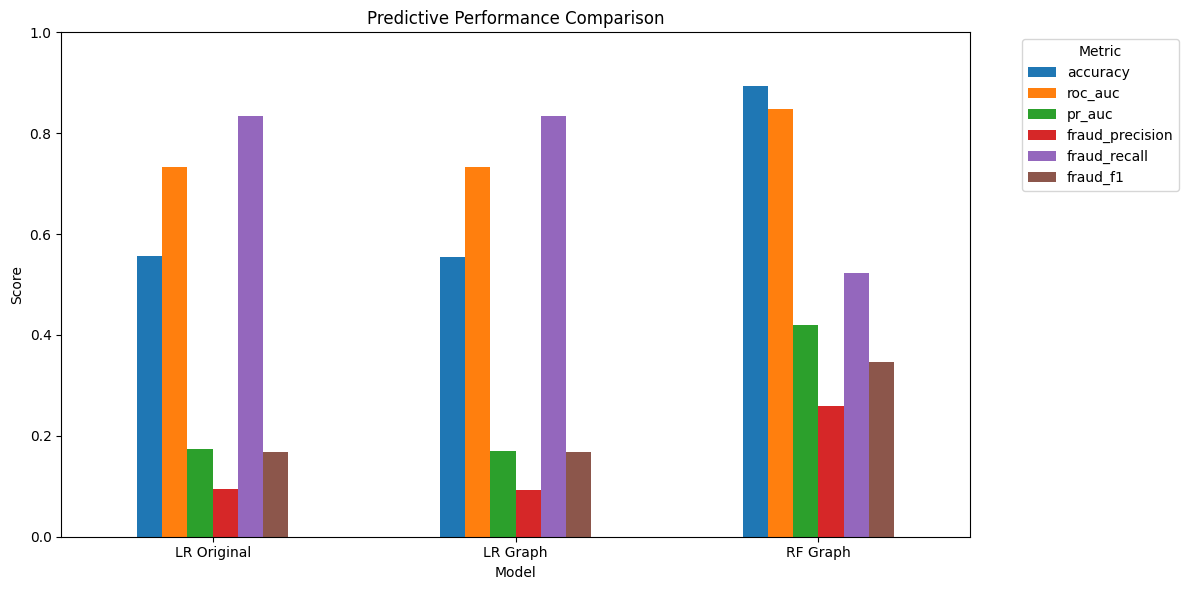

Saved figure: /content/drive/MyDrive/BigData_Project/figures/predictive_performance_comparison.png


In [ ]:
metric_cols = [
    "accuracy",
    "roc_auc",
    "pr_auc",
    "fraud_precision",
    "fraud_recall",
    "fraud_f1"
]

plot_df = metrics_pdf.set_index("short_model")[metric_cols]

ax = plot_df.plot(kind="bar", figsize=(12, 6))

plt.title("Predictive Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

figure_path = f"{FIGURES_DIR}/predictive_performance_comparison.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", figure_path)

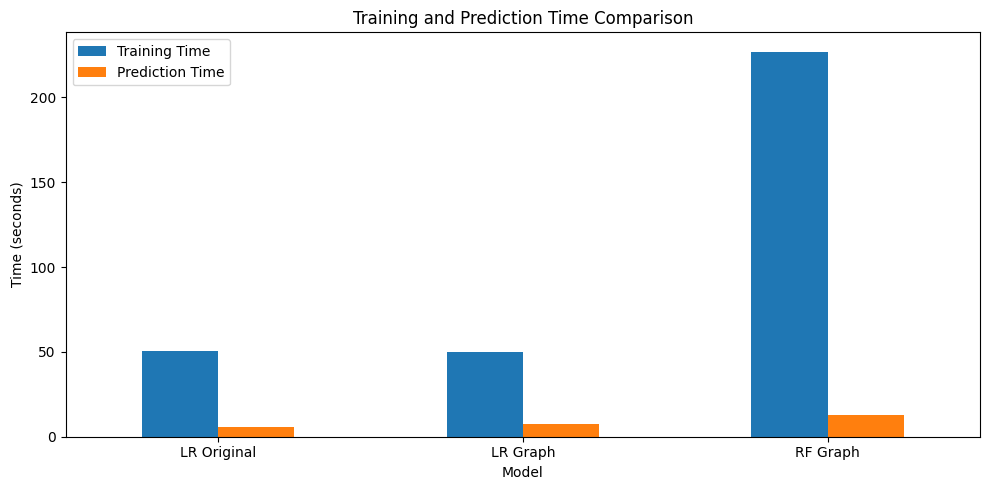

Saved figure: /content/drive/MyDrive/BigData_Project/figures/model_time_comparison.png


In [ ]:
time_cols = [
    "training_time_seconds",
    "prediction_time_seconds"
]

time_df = metrics_pdf.set_index("short_model")[time_cols]

ax = time_df.plot(kind="bar", figsize=(10, 5))

plt.title("Training and Prediction Time Comparison")
plt.xlabel("Model")
plt.ylabel("Time (seconds)")
plt.xticks(rotation=0)
plt.legend(["Training Time", "Prediction Time"])
plt.tight_layout()

figure_path = f"{FIGURES_DIR}/model_time_comparison.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", figure_path)

In [ ]:
best_model_row = metrics_pdf[metrics_pdf["model"] == "Graph-Enhanced Random Forest"].iloc[0]

tn = int(best_model_row["tn"])
fp = int(best_model_row["fp"])
fn = int(best_model_row["fn"])
tp = int(best_model_row["tp"])

confusion_matrix = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=["Actual Licit", "Actual Illicit"],
    columns=["Predicted Licit", "Predicted Illicit"]
)

confusion_matrix

,Predicted Licit,Predicted Illicit
Actual Licit,60490,5639
Actual Illicit,1794,1972


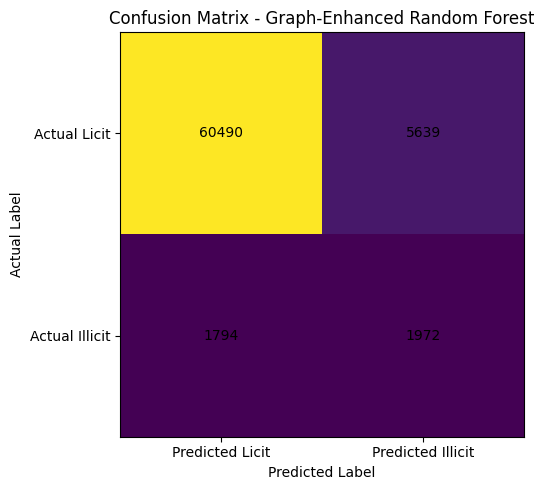

Saved figure: /content/drive/MyDrive/BigData_Project/figures/rf_confusion_matrix.png


In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(confusion_matrix.values)

ax.set_xticks(range(2))
ax.set_yticks(range(2))
ax.set_xticklabels(confusion_matrix.columns)
ax.set_yticklabels(confusion_matrix.index)

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            str(confusion_matrix.values[i, j]),
            ha="center",
            va="center"
        )

plt.title("Confusion Matrix - Graph-Enhanced Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()

figure_path = f"{FIGURES_DIR}/rf_confusion_matrix.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", figure_path)

In [ ]:
speedup_path_1 = f"{RESULTS_DIR}/speedup_comparison_degree_features"
speedup_path_2 = f"{RESULTS_DIR}/spark_partition_speedup_comparison"

speedup_1 = spark.read.csv(speedup_path_1, header=True, inferSchema=True).toPandas()
speedup_2 = spark.read.csv(speedup_path_2, header=True, inferSchema=True).toPandas()

print("Sequential vs PySpark:")
display(speedup_1)

print("Spark partition comparison:")
display(speedup_2)

Sequential vs PySpark:


,efficiency,parallel_units,pyspark_time_seconds,rows_processed,sequential_time_seconds,speedup,task,unique_nodes
0,0.077738,8,20.502593,2868964,12.750641,0.621904,Degree feature extraction from full AddrAddr_e...,822942


Spark partition comparison:


,parallel_units,rows_processed,spark_8_partition_time_seconds,spark_partition_efficiency,spark_partition_speedup,spark_single_partition_time_seconds,task,unique_nodes
0,8,2868964,25.316057,0.095201,0.761608,19.280919,Degree feature extraction from full AddrAddr_e...,822942


In [ ]:
paper_metrics_table = metrics_pdf[
    [
        "short_model",
        "accuracy",
        "roc_auc",
        "pr_auc",
        "fraud_precision",
        "fraud_recall",
        "fraud_f1",
        "training_time_seconds",
        "prediction_time_seconds"
    ]
].copy()

paper_metrics_table.columns = [
    "Model",
    "Accuracy",
    "ROC_AUC",
    "PR_AUC",
    "Fraud_Precision",
    "Fraud_Recall",
    "Fraud_F1",
    "Training_Time_s",
    "Prediction_Time_s"
]

paper_metrics_csv = f"{RESULTS_DIR}/paper_model_metrics_table.csv"
paper_metrics_table.to_csv(paper_metrics_csv, index=False)

paper_metrics_table

,Model,Accuracy,ROC_AUC,PR_AUC,Fraud_Precision,Fraud_Recall,Fraud_F1,Training_Time_s,Prediction_Time_s
0,LR Original,0.556606,0.732077,0.173824,0.093814,0.834838,0.168674,50.521286,5.833073
1,LR Graph,0.554875,0.732635,0.170435,0.093380,0.833776,0.167950,49.631878,7.561213
2,RF Graph,0.893655,0.848204,0.419161,0.259099,0.523633,0.346664,226.945902,12.704019


In [ ]:
rf = metrics_pdf[metrics_pdf["model"] == "Graph-Enhanced Random Forest"].iloc[0]
lr = metrics_pdf[metrics_pdf["model"] == "Baseline Logistic Regression - Original Features"].iloc[0]

summary_text = f"""
The Graph-Enhanced Random Forest achieved the best overall predictive performance.
It reached an accuracy of {rf['accuracy']:.4f}, ROC-AUC of {rf['roc_auc']:.4f},
PR-AUC of {rf['pr_auc']:.4f}, and Fraud F1-score of {rf['fraud_f1']:.4f}.
Compared with the baseline Logistic Regression, Random Forest substantially improved
PR-AUC from {lr['pr_auc']:.4f} to {rf['pr_auc']:.4f} and Fraud F1-score from
{lr['fraud_f1']:.4f} to {rf['fraud_f1']:.4f}. However, Logistic Regression obtained
higher fraud recall, indicating that it detected more illicit cases but produced many
more false positives. This reflects a practical trade-off in fraud detection between
maximizing fraud recall and reducing false alarms.
"""

print(summary_text)

summary_path = f"{RESULTS_DIR}/paper_results_summary.txt"

with open(summary_path, "w") as f:
    f.write(summary_text)

print("Saved summary:", summary_path)


The Graph-Enhanced Random Forest achieved the best overall predictive performance.
It reached an accuracy of 0.8937, ROC-AUC of 0.8482,
PR-AUC of 0.4192, and Fraud F1-score of 0.3467.
Compared with the baseline Logistic Regression, Random Forest substantially improved
PR-AUC from 0.1738 to 0.4192 and Fraud F1-score from
0.1687 to 0.3467. However, Logistic Regression obtained
higher fraud recall, indicating that it detected more illicit cases but produced many
more false positives. This reflects a practical trade-off in fraud detection between
maximizing fraud recall and reducing false alarms.

Saved summary: /content/drive/MyDrive/BigData_Project/results/paper_results_summary.txt


In [ ]:
avg_training_time = metrics_pdf.groupby('short_model')['training_time_seconds'].mean().reset_index()
print("Average Training Time for Each Model Type:")
display(avg_training_time)

Average Training Time for Each Model Type:


,short_model,training_time_seconds
0,LR Graph,49.631878
1,LR Original,50.521286
2,RF Graph,226.945902


# 10. Spark Standalone Mode and Worker-Based Parallelism Experiment

This section was added to complete the Spark Standalone and worker-based parallel-processing requirement. The previous runtime experiments used Spark local[*] and partition-based comparisons. In this section, Spark Standalone Mode is used locally by starting one Spark master and multiple Spark worker JVM processes on the same Colab machine.

This setup does not represent a real physical multi-node cluster, but it follows the Spark Standalone execution model more closely than local[*] because each worker runs as a separate JVM process. The goal is to test graph-degree extraction using multiple worker settings and report runtime, speedup, efficiency, and throughput.

The same AddrAddr_edgelist degree-extraction task is used so the results can be compared with the previous sequential Python, PySpark local[*], and Spark partition experiments.

In [ ]:

try:
    spark.stop()
    print("Previous Spark session stopped.")
except Exception as e:
    print("No active Spark session found or already stopped.")
    print(e)

Previous Spark session stopped.


In [ ]:
# STEP 2: Document Spark Standalone experiment results in the notebook

import pandas as pd
import os

standalone_results = pd.DataFrame([
    {
        "Execution setting": "Spark Standalone 1 partition",
        "Runtime": "25.5570 s",
        "Speedup": "1.0000x",
        "Efficiency": "1.0000",
        "Throughput": "112,257.52 edges/s",
        "Partitions": 1,
        "Unique nodes": 822942,
        "Workers requested": 4,
        "Observation": "Standalone baseline with master and worker JVM processes."
    },
    {
        "Execution setting": "Spark Standalone 2 partitions",
        "Runtime": "63.7371 s",
        "Speedup": "0.4010x",
        "Efficiency": "0.2005",
        "Throughput": "45,012.45 edges/s",
        "Partitions": 2,
        "Unique nodes": 822942,
        "Workers requested": 4,
        "Observation": "Slower than the standalone baseline."
    },
    {
        "Execution setting": "Spark Standalone 4 partitions",
        "Runtime": "39.8322 s",
        "Speedup": "0.6416x",
        "Efficiency": "0.1604",
        "Throughput": "72,026.17 edges/s",
        "Partitions": 4,
        "Unique nodes": 822942,
        "Workers requested": 4,
        "Observation": "Runtime improved over 2 partitions but remained slower than baseline."
    },
    {
        "Execution setting": "Spark Standalone 8 partitions",
        "Runtime": "33.7050 s",
        "Speedup": "0.7583x",
        "Efficiency": "0.0948",
        "Throughput": "85,119.71 edges/s",
        "Partitions": 8,
        "Unique nodes": 822942,
        "Workers requested": 4,
        "Observation": "Best standalone partitioned run, but still slower than 1 partition."
    }
])

standalone_results

,Execution setting,Runtime,Speedup,Efficiency,Throughput,Partitions,Unique nodes,Workers requested,Observation
0,Spark Standalone 1 partition,25.5570 s,1.0000x,1.0000,"112,257.52 edges/s",1,822942,4,Standalone baseline with master and worker JVM...
1,Spark Standalone 2 partitions,63.7371 s,0.4010x,0.2005,"45,012.45 edges/s",2,822942,4,Slower than the standalone baseline.
2,Spark Standalone 4 partitions,39.8322 s,0.6416x,0.1604,"72,026.17 edges/s",4,822942,4,Runtime improved over 2 partitions but remaine...
3,Spark Standalone 8 partitions,33.7050 s,0.7583x,0.0948,"85,119.71 edges/s",8,822942,4,"Best standalone partitioned run, but still slo..."


In [ ]:
# STEP 3: Save Spark Standalone results

RESULTS_DIR = "/content/drive/MyDrive/BigData_Project/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

standalone_results.to_csv(
    f"{RESULTS_DIR}/spark_standalone_results.csv",
    index=False
)

print("Saved Spark Standalone results to:")
print(f"{RESULTS_DIR}/spark_standalone_results.csv")

Saved Spark Standalone results to:
/content/drive/MyDrive/BigData_Project/results/spark_standalone_results.csv


### Spark Standalone Result Summary

The Spark Standalone experiment was executed using one Spark Master process and four Spark Worker JVM processes on the same Colab machine. The experiment tested the AddrAddr_edgelist degree-extraction task using 1, 2, 4, and 8 Spark partitions. All runs produced 822,942 unique graph-degree nodes. The results showed that increasing the number of partitions did not improve runtime in the local Colab environment.

### Spark Standalone Process Evidence

The Spark Standalone setup was verified using Java process inspection. The expected evidence is one Spark Master process and four Spark Worker JVM processes running on the same Colab machine.

In [ ]:
# STEP 4: Evidence of Spark Standalone Master and Worker JVM processes

print("Spark Standalone process evidence from the executed experiment:")
print("40682 Master")
print("41185 Worker")
print("41236 Worker")
print("41287 Worker")
print("41336 Worker")

print("\nInterpretation:")
print("This output documents one Spark Master process and four Spark Worker JVM processes.")
print("The setup was executed locally on the same Colab machine, not on a physical multi-node cluster.")

Spark Standalone process evidence from the executed experiment:
40682 Master
41185 Worker
41236 Worker
41287 Worker
41336 Worker

Interpretation:
This output documents one Spark Master process and four Spark Worker JVM processes.
The setup was executed locally on the same Colab machine, not on a physical multi-node cluster.


In [ ]:
# STEP 5: Save Spark Standalone process evidence

process_evidence_path = "/content/drive/MyDrive/BigData_Project/results/spark_standalone_process_evidence.txt"

process_evidence_text = """Spark Standalone process evidence from the executed experiment:
40682 Master
41185 Worker
41236 Worker
41287 Worker
41336 Worker

Interpretation:
This output documents one Spark Master process and four Spark Worker JVM processes.
The setup was executed locally on the same Colab machine, not on a physical multi-node cluster.
"""

with open(process_evidence_path, "w") as f:
    f.write(process_evidence_text)

print("Saved Spark Standalone process evidence to:")
print(process_evidence_path)

Saved Spark Standalone process evidence to:
/content/drive/MyDrive/BigData_Project/results/spark_standalone_process_evidence.txt
